In [1]:
import glob
import os
import numpy as np
import pandas as pd
from aeon.visualisation import plot_critical_difference, create_multi_comparison_matrix
from labicompare.visualization import critical_difference_diagram, generate_mcm
import matplotlib.pyplot as plt

# TSER

In [2]:
my_models = {
    "MultiRocket-TabPFN": 'tser/' + "results/Tab_multi.csv",
    "TsFresh-TabPFN": 'tser/' + "results/Tab_tsfresh.csv",
    "C22-TabPFN": 'tser/' + "results/Tab_c22.csv",
}
metric_name = "RMSE"

In [3]:
results = {}

for model_name, path in my_models.items():
    # 1. Carregar garantindo o índice
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.astype(str)
    
    # 2. Extrair apenas colunas numéricas e calcular a média
    mean_scores = df.select_dtypes(include="number").mean(axis=1)
    results[model_name] = mean_scores

# 3. Criar o DataFrame (Equivalente ao seu template de métricas)
combined = pd.DataFrame(results).dropna()

print("Datasets usados:", len(combined))

Datasets usados: 55


Index(['C22-TabPFN', 'MultiRocket-TabPFN', 'TsFresh-TabPFN'], dtype='object')


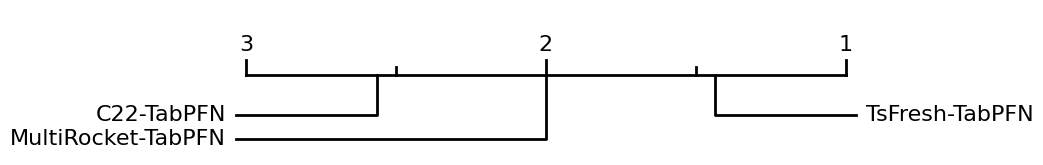

In [4]:
fig = critical_difference_diagram(
    metrics=-combined,
    test='wilcoxon',
    alpha=0.05
)

In [5]:
model_files = {
    "TsFresh-TabPFN": 'tser/' + "results/Tab_tsfresh.csv",
    "MiniROCKET": 'tser/' + "results/MiniROCKET.csv",
    "DrCIF": 'tser/' + "results/DrCIF.csv",
    "FreshPRINCE": 'tser/' + "results/FreshPRINCE.csv",
    "InceptionT": 'tser/' + "results/InceptionT.csv",
    "MultiROCKET": 'tser/' + "results/MultiROCKET.csv",
    "RotF": 'tser/' + "results/RotF.csv",
    # "TSF": 'tser/' + "results/TSF.csv",
    # "RandF": 'tser/' + "results/RandF.csv",
    # "ResNet": 'tser/' + "results/ResNet.csv",
    # "Ridge": 'tser/' + "results/Ridge.csv",
    # "ROCKET": 'tser/' + "results/ROCKET.csv",
    # "XGBoost": 'tser/' + "results/XGBoost.csv",
    # "CNN": 'tser/' + "results/CNN.csv",
}
lower_better = True

In [6]:
results = {}

for model_name, path in model_files.items():
    # 1. Carregar garantindo o índice
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.astype(str)
    
    # 2. Extrair apenas colunas numéricas e calcular a média
    mean_scores = df.select_dtypes(include="number").mean(axis=1)
    results[model_name] = mean_scores

# 3. Criar o DataFrame (Equivalente ao seu template de métricas)
combined = pd.DataFrame(results).dropna()

print("Datasets usados:", len(combined))

Datasets usados: 55


Index(['MultiROCKET', 'RotF', 'InceptionT', 'MiniROCKET', 'FreshPRINCE',
       'DrCIF', 'TsFresh-TabPFN'],
      dtype='object')
[0, 1, 2, 3, 4, 5]


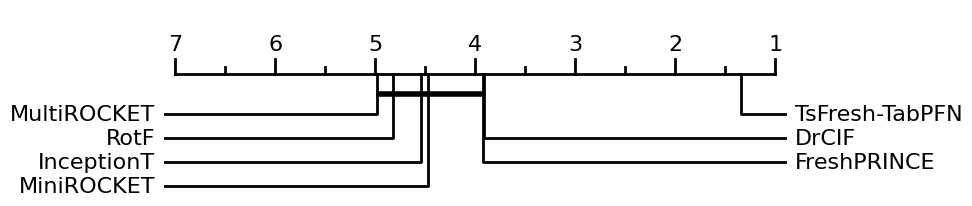

In [7]:
fig = critical_difference_diagram(
    metrics=-combined,
    test='wilcoxon',
    alpha=0.05
)

Processing MiniROCKET, FreshPRINCE:   0%|          | 0/4 [00:00<?, ?it/s]    


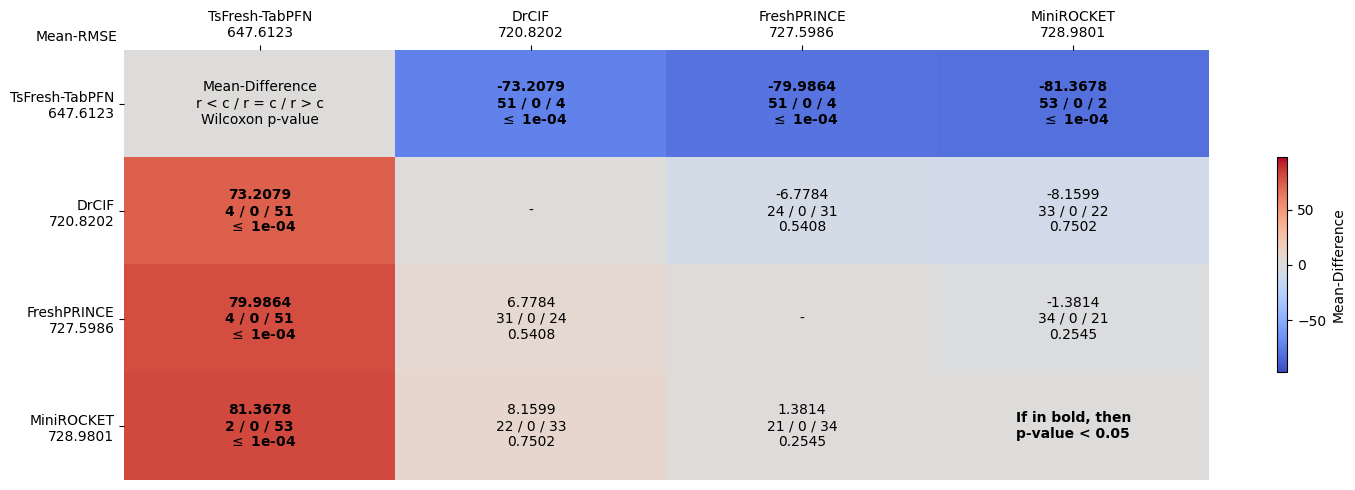

In [8]:
combined = combined[['TsFresh-TabPFN','DrCIF','FreshPRINCE','MiniROCKET']]

fig = generate_mcm(
    metrics=combined,
    used_statistic="RMSE",
    order_better="increasing",
    order_WinTieLoss="lower",
    win_label="r < c",
    loss_label="r > c",
    tie_label="r = c",
    colormap="coolwarm"
)

fig.show()

# TSC

In [9]:
my_models = {
    "MultiRocket-TabPFN": 'tsc/' + "results/Tab_multi.csv",
    "TsFresh-TabPFN": 'tsc/' + "results/Tab_tsfresh.csv",
    "C22-TabPFN": 'tsc/' + "results/Tab_c22.csv",
}
metric_name = "Accuracy"

In [10]:
results = {}

for model_name, path in my_models.items():
    # 1. Carregar garantindo o índice
    df = pd.read_csv(path, index_col=0)
    df.index = df.index.astype(str)
    
    # 2. Extrair apenas colunas numéricas e calcular a média
    mean_scores = df.select_dtypes(include="number").mean(axis=1)
    results[model_name] = mean_scores

# 3. Criar o DataFrame (Equivalente ao seu template de métricas)
combined = pd.DataFrame(results).dropna()

print("Datasets usados:", len(combined))

Datasets usados: 134


Index(['C22-TabPFN', 'TsFresh-TabPFN', 'MultiRocket-TabPFN'], dtype='object')


/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


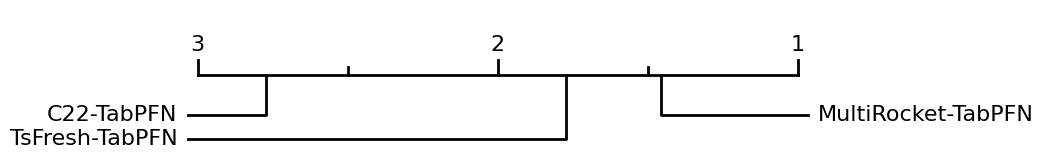

In [11]:
fig = critical_difference_diagram(
    metrics=combined,
    test='wilcoxon',
    alpha=0.05
)

In [12]:
UNI_BASE = "/home/gcmerlin/exp/tabpfn-for-tsc-tser/tsc/results/Univariate"
MULTI_BASE = "/home/gcmerlin/exp/tabpfn-for-tsc-tser/tsc/results/Multivariate"

# Pegar arquivos
uni_files = glob.glob(UNI_BASE + "/*_accuracy.csv")
multi_files = glob.glob(MULTI_BASE + "/*_accuracy.csv")

def extract_model_name(path):
    return os.path.basename(path).replace("_accuracy.csv", "")

uni_models = {extract_model_name(f): f for f in uni_files}
multi_models = {extract_model_name(f): f for f in multi_files}

# Interseção
common_models = sorted(set(uni_models) & set(multi_models))

# --------------------------------------------------
# DICT FINAL (o que você quer)
# --------------------------------------------------

model_files = {
    model: [
        uni_models[model],
        multi_models[model],
    ]
    for model in common_models
}

model_files['MultiROCKET-TabPFN'] = 'tsc/results/Tab_multi.csv'

metric_name = "accuracy"
lower_better = False

In [13]:
results = {}

for model_name, paths in model_files.items():

    # 🔒 Garantir que sempre seja lista
    if isinstance(paths, str):
        paths = [paths]

    model_series_list = []

    for path in paths:

        df = pd.read_csv(path, index_col=0)
        df.index = df.index.astype(str)
        df = df.select_dtypes(include="number")

        mean_scores = df.mean(axis=1)
        model_series_list.append(mean_scores)

    combined_model_scores = pd.concat(model_series_list)

    results[model_name] = combined_model_scores


combined = pd.concat(results, axis=1)
combined = combined.dropna()

print("Datasets usados:", len(combined))

Datasets usados: 134


Index(['DrCIF', 'HC1', 'Arsenal', 'ROCKET', 'MultiROCKET-TabPFN', 'HC2'], dtype='object')
[0, 1, 2, 3]
[4, 5]


/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/gcmerlin/miniconda3/envs/tabs/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


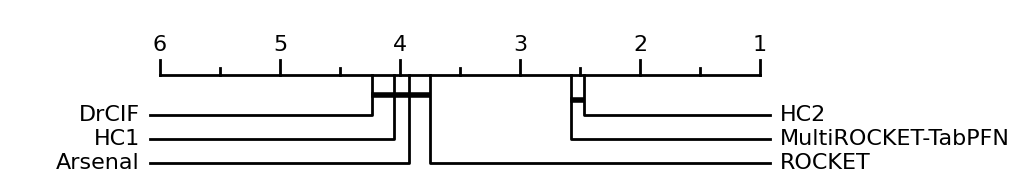

In [14]:
combined = combined[['DrCIF','Arsenal', 'HC1', 'ROCKET', 'MultiROCKET-TabPFN', 'HC2']]

fig = critical_difference_diagram(
    metrics=combined,
    test='wilcoxon',
    alpha=0.05
)

Processing HC2, MultiROCKET-TabPFN:   0%|          | 0/3 [00:00<?, ?it/s]   


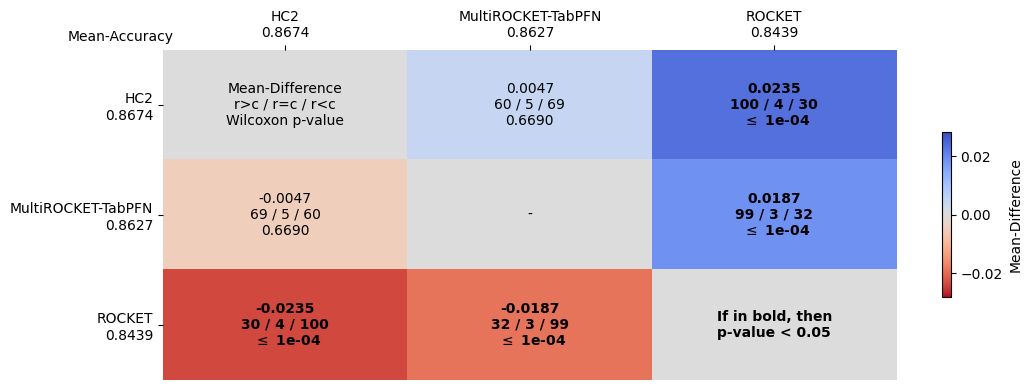

In [15]:
combined = combined[['ROCKET', 'MultiROCKET-TabPFN', 'HC2']]

fig = generate_mcm(
    metrics=combined,
    colormap='coolwarm_r'
)
fig.show()